# IPS from scratch: the engine sequence behind a rare-event estimate

Loss of separation under a working CDR chain is *rare* — a plain Monte-Carlo run of
10⁴ encounters can return **zero** events and tell you nothing. Interacting particle
system (IPS) splitting gets the number anyway: nest the rare event in **shells** of the
running-minimum separation, keep a fixed cloud of `N` particles, and at each shell
throw away the particles that never got that close and clone the ones that did. The
estimate is the product of the survival fractions, `P̂ = Π_k S_k/N`.

The whole method rests on one capability of the simulator: **you must be able to freeze
an encounter mid-flight and resume it more than once**. This notebook builds the
estimator on top of that, from scratch, in its own cells:

1. **one encounter in BlueSky** — spawn, step, watch the running minimum fall,
2. **freeze and resume** — the snapshot/restore contract that makes cloning possible,
3. **the estimator** — particle, evolve, freeze, resample, in ~50 lines,
4. **the ladder** — cull and resample down to the protected zone,
5. **the cross-check** — the packaged `estimate_rare_prob` must reproduce it exactly.

> **The from-scratch rule.** Everything IPS-specific below is written out in these
> cells; only the *simulator* is imported (`engine`, `episode`, `rng`, `config`, and the
> top-level `PairwiseEncounter` / `MULTIROTOR`).
> `blueskycdarr.ips` is imported in exactly one place — the final verification cell —
> and only to check the result. The bodies here are the package's own
> ([`blueskycdarr/ips.py`](../blueskycdarr/ips.py), ADR 0008), copied rather than called.
> For the complementary view — the packaged estimator opened up, with the particle
> cloud drawn — see [`ips_walkthrough.ipynb`](ips_walkthrough.ipynb).

The cell under study: crossing angle **90°**, head-on miss distance 0 m,
`pos_ci95 = 40 m`, `vel_ci95 = 1 m/s`, reception 0.8, latency 0.3 s, protected zone
`rpz = 50 m`.

In [21]:
import matplotlib.pyplot as plt
import numpy as np

from blueskycdarr import MULTIROTOR, Config, PairwiseEncounter
from blueskycdarr.config import CommConfig, SimulationConfig, UncertaintyConfig
from blueskycdarr.engine import (
    PairwiseWorld,
    WorldSnapshot,
    discard_pending_commands,
    reset_world,
)
from blueskycdarr.episode import (
    EpisodeState,
    EpisodeStreams,
    advance,
    episode_context,
    init_episode,
)
from blueskycdarr.rng import child, generator, root_seed_sequence

# --- the cell ---------------------------------------------------------------------
DPSI, POS_CI95, VEL_CI95 = 90.0, 40.0, 1.0
N, LEVELS, SEED = 20, [95.0, 85.0, 70.0, 50.0], 4
RPZ = 50.0

SCENARIO = PairwiseEncounter(pairs=(1, 1), dpsi=DPSI, dcpa=0.0, tlos=20.0)
CONFIG = Config(
    uncertainty=UncertaintyConfig(pos_ci95=POS_CI95, vel_ci95=VEL_CI95),
    comm=CommConfig(reception_prob=0.8, latency_s=0.3),
    simulation=SimulationConfig(t_max=90.0),
)
# Per-cell constants shared read-only by every particle: config + models, derived once.
ctx = episode_context(SCENARIO.n_pairs, MULTIROTOR, CONFIG)
DT = CONFIG.simulation.dt

# --- plotting style (blue/orange/aqua + neutral grays) -----------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GRAY, INK, MUTED, RED = "#b6b5ae", "#0b0b0b", "#52514e", "#e34948"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.edgecolor": MUTED,
    "axes.labelcolor": INK, "text.color": INK, "xtick.color": MUTED,
    "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#eeedea", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.constrained_layout.use": True,
})

def _levels_on(ax, levels=LEVELS):
    """Draw the ladder's shells as horizontal lines; the rpz boundary in red."""
    for d in levels:
        is_rpz = d == RPZ
        ax.axhline(d, color=RED if is_rpz else MUTED, lw=1.4 if is_rpz else 0.9,
                   ls="--", alpha=0.9 if is_rpz else 0.55, zorder=1)
        ax.annotate(f"{d:g} m" + (" = rpz" if is_rpz else ""),
                    xy=(1.0, d), xycoords=("axes fraction", "data"),
                    xytext=(4, 0), textcoords="offset points",
                    va="center", fontsize=8.5, color=RED if is_rpz else MUTED)

print(f"integration step dt = {DT} s, CDR cadence {CONFIG.simulation.cdr_dt} s, "
      f"t_max = {CONFIG.simulation.t_max} s")

integration step dt = 0.2 s, CDR cadence 1.0 s, t_max = 90.0 s


## 1 · One encounter in BlueSky

The simplest thing the engine does: fly a single ownship/intruder pair. Three calls set
it up.

- `SCENARIO.draw_geometry(...)` draws the spawn parameters. In *this* cell the crossing
  angle and miss distance are pinned (90°, 0 m) and the speeds default to 15 m/s, so
  every encounter starts from the same geometry — the randomness that separates
  encounters here is the **broadcast phase** and the forward GNSS/reception noise.
- `PairwiseWorld(...)` puts the pair into the process-global BlueSky: the ownship via
  `cre`, the intruder via the CDaRR fork's `creconfs`, which places it *already in
  conflict* — `tlos = 20 s` from loss of separation at spawn.
- `init_episode(...)` builds the episode state: the broadcast channel, the contact
  table, the commands being flown, and `min_sep` — the running minimum true separation,
  seeded at `inf`.

Then `advance(world, ctx, state, streams)` is one integration step: observe truth
(updating `min_sep`), fire and land broadcasts, run the CDR tick when due, check the
stop conditions, and step BlueSky. It returns `False` once the encounter has ended.
`min_sep` is the **level function** the whole estimator is built on — being a running
minimum it never increases, so shell crossings are one-way.

In [23]:
DEMO_SEQ = child(root_seed_sequence(SEED), 99)   # a scratch corner of the stream tree

geometry = SCENARIO.draw_geometry(generator(child(DEMO_SEQ, 0)))
world = PairwiseWorld(SCENARIO, geometry, MULTIROTOR, CONFIG.conflict, CONFIG.simulation)
state = init_episode(world, ctx, EpisodeStreams.from_episode_seq(DEMO_SEQ))
streams = EpisodeStreams.from_episode_seq(DEMO_SEQ)

print(f"spawned  dpsi = {geometry.dpsi[0]:.0f}°   dcpa = {geometry.dcpa[0]:.0f} m   "
      f"gs_own = {geometry.gs_own[0]:.1f} m/s   gs_intr = {geometry.gs_intr[0]:.1f} m/s")
print(f"{'step':>5} {'t [s]':>7} {'separation [m]':>15} {'min_sep [m]':>13}")
for _ in range(10):
    t, sep = state.step * DT, float(world.pair_distances()[0])
    advance(world, ctx, state, streams)      # observes at t, then steps the engine
    print(f"{state.step - 1:5d} {t:7.1f} {sep:15.2f} {float(state.min_sep[0]):13.2f}")

spawned  dpsi = 90°   dcpa = 0 m   gs_own = 15.0 m/s   gs_intr = 15.0 m/s
 step   t [s]  separation [m]   min_sep [m]
    0     0.0          475.11        475.11
    1     0.2          470.86        470.86
    2     0.4          466.61        466.61
    3     0.6          462.37        462.37
    4     0.8          458.12        458.12
    5     1.0          453.87        453.87
    6     1.2          449.63        449.63
    7     1.4          445.30        445.30
    8     1.6          440.96        440.96
    9     1.8          436.62        436.62


## 2 · Freeze and resume — the contract splitting is built on

Splitting needs to take one promising trajectory and continue it **several times over**,
each continuation seeing different noise. That requires two things from the simulator,
and this cell demonstrates both.

`world.snapshot()` copies the entire global BlueSky world — every registered traffic
array, the fork's turn-rate limiter memory, the conflict bookkeeping, the clock and its
timers — into a plain `WorldSnapshot` value. `state.copy()` copies the episode half.
Together they are a **particle**. Snapshots are only legal at a *post-step boundary*
(right after `advance` returned `True`), because that is when BlueSky's command stack is
empty; the engine refuses otherwise rather than silently dropping pending commands.

What separates two clones of one particle is not the frozen state, which they share, but
the **forward random streams** they are handed when they fly again. So:

- restore the same snapshot and fly with the **same** stream bundle → the trajectory is
  reproduced *exactly*, to the last bit (the assert below);
- restore it and fly with a **different** bundle → same past, different future.

Below, leg **A** is flown, the world is rewound, **A is replayed**, then the world is
rewound once more and leg **B** is flown on a different stream bundle.

In [24]:
while state.step < 50 and not state.ended:      # fly into the thick of the encounter
    advance(world, ctx, state, streams)

snap, saved = world.snapshot(), state.copy()    # <- the particle: engine half + episode half
print(f"froze at step {state.step} (t = {state.step * DT:.1f} s), "
      f"separation {float(world.pair_distances()[0]):.2f} m, ended = {state.ended}")

SEQ_A, SEQ_B = child(DEMO_SEQ, 101), child(DEMO_SEQ, 102)

def fly_leg(snapshot, base, seq, n_steps):
    """Rewind to `snapshot`/`base` and fly `n_steps`, returning the separation series."""
    world.restore(snapshot)
    s, bundle = base.copy(), EpisodeStreams.from_episode_seq(seq)
    out = []
    for _ in range(n_steps):
        if not advance(world, ctx, s, bundle):
            break
        out.append(float(world.pair_distances()[0]))
    return np.array(out)

leg_a1 = fly_leg(snap, saved, SEQ_A, 25)        # leg A
leg_a2 = fly_leg(snap, saved, SEQ_A, 25)        # leg A, replayed from the same snapshot
leg_b = fly_leg(snap, saved, SEQ_B, 25)         # leg B: same past, fresh noise

print(f"\n{'+t [s]':>7} {'A [m]':>10} {'A replayed [m]':>16} {'B [m]':>10}")
for i in (0, 4, 9, 14, 19, 24):
    print(f"{(i + 1) * DT:7.1f} {leg_a1[i]:10.3f} {leg_a2[i]:16.3f} {leg_b[i]:10.3f}")

assert np.array_equal(leg_a1, leg_a2), "same snapshot + same streams must replay exactly"
assert not np.array_equal(leg_a1, leg_b), "fresh streams must diverge"
print(f"\nA vs A replayed : bit-identical ({len(leg_a1)} steps)")
print(f"A vs B          : diverged, max separation gap "
      f"{float(np.max(np.abs(leg_a1 - leg_b))):.2f} m after {len(leg_b) * DT:.0f} s")
reset_world()

froze at step 50 (t = 10.0 s), separation 260.63 m, ended = False

 +t [s]      A [m]   A replayed [m]      B [m]
    0.2    256.642          256.642    256.539
    1.0    241.027          241.027    240.234
    2.0    221.594          221.594    220.005
    3.0    203.367          203.367    199.993
    4.0    185.926          185.926    180.274
    5.0    170.370          170.370    160.954

A vs A replayed : bit-identical (25 steps)
A vs B          : diverged, max separation gap 9.42 m after 5 s


## 3 · The estimator, from scratch

That is everything the method needs. The estimator is now four small pieces:

- **`Particle`** — an encounter frozen at a post-step boundary: a `WorldSnapshot` beside
  an `EpisodeState`. `world is None` marks an encounter that has **ended** (settled, or
  hit `t_max`); its future is closed, so no engine state is kept and it never touches the
  simulator again. `min_sep` reads the level function off the episode half.
- **`spawn_particle`** — materialise a fresh encounter from a seed. Child 0 of the seed
  draws the geometry and the bundle supplies the broadcast phase, laid out exactly like a
  Monte-Carlo episode seed, so the initial cloud samples the same encounter distribution
  MC integrates over. That is what makes the two estimators comparable.
- **`evolve_to_level`** — advance until the running minimum crosses `target` **or** the
  encounter ends. Crossing is judged between whole steps, and survivor status is read off
  `min_sep` afterwards, never off which condition broke the loop.
- **`freeze` / `resample_level`** — package the result, then apply the level's barrier:
  survivors (`min_sep <= target`) are drawn **with replacement** back up to `N`. An
  encounter that ends exactly on a CDR tick can leave commands stacked but never flown;
  they belong to no future, so `freeze` discards them — otherwise they would trip the
  next particle's restore guard.

Note what `resample_level` does *not* do: it hands clones nothing that makes them
independent. That comes only from the fresh stream bundle each clone is given when it
flies again — section 2's contract, load-bearing.

In [4]:
from dataclasses import dataclass


@dataclass(frozen=True)
class Particle:
    """One IPS particle: an encounter frozen at a post-step boundary."""

    world: WorldSnapshot | None      # None = the encounter ended; its future is closed
    episode: EpisodeState

    @property
    def min_sep(self) -> float:
        """The encounter's running-minimum separation [m] — the level function."""
        return float(self.episode.min_sep[0])


def spawn_particle(seed):
    """Materialise one initial-cloud particle: geometry from child 0, episode fresh."""
    geom = SCENARIO.draw_geometry(generator(child(seed, 0)))
    w = PairwiseWorld(SCENARIO, geom, MULTIROTOR, CONFIG.conflict, CONFIG.simulation)
    return w, init_episode(w, ctx, EpisodeStreams.from_episode_seq(seed))


def evolve_to_level(w, st, bundle, target, recorder=None):
    """Advance until the running minimum crosses `target` or the encounter ends."""
    running = not st.ended
    while running and float(st.min_sep[0]) > target:
        running = advance(w, ctx, st, bundle, recorder=recorder)


def freeze(w, st):
    """Package an evolved state as a shareable particle; ended encounters keep no world."""
    if st.ended:
        discard_pending_commands()      # a dead world's unflown commands belong to no future
        return Particle(world=None, episode=st)
    return Particle(world=w.snapshot(), episode=st)


def resample_level(evolved, target, n_particles, seq):
    """One level's barrier: survival fraction, resampled cloud, distinct-lineage count."""
    survivors = [p for p in evolved if p.min_sep <= target]
    fraction = len(survivors) / n_particles
    if not survivors:
        return fraction, [], 0          # the level collapsed
    idx = generator(seq).integers(0, len(survivors), size=n_particles)
    return fraction, [survivors[i] for i in idx], len(set(idx.tolist()))


print("estimator defined:", ", ".join(
    f.__name__ for f in (spawn_particle, evolve_to_level, freeze, resample_level)))

estimator defined: spawn_particle, evolve_to_level, freeze, resample_level


## 4 · The ladder

One replication, assembled from those pieces. Per level `k`:

- **level 0** spawns each particle fresh and flies it to the first shell;
- **later levels** either skip the particle (it has *ended*, or it already **overshot**
  this shell — decided by the accumulated minimum alone, with no engine work) or restore
  its snapshot into the one live world, copy its episode half, and fly it on a **fresh**
  per-clone bundle;
- then the barrier: cull, resample, record `S_k/N`.

BlueSky is a process-global singleton, so there is only ever *one* live world; the cloud
is **time-multiplexed** through it, one particle at a time. The `finally` clears the
traffic however the run exits.

The seed addressing is the fiddly part, and it is what section 5 checks. It mirrors the
package exactly: `init_seq = child(seq, 0)`, `evolve_seq = child(seq, 1)`, level `k` uses
`level_seq = child(evolve_seq, k)`, particle `i` evolves on `child(level_seq, i)`, and
the level's resampling draw is `child(level_seq, N)`. Addressing is stateless (`child`,
never `spawn`), so rebuilding any bundle draws the same numbers.

`advance` takes an observer hook that is handed `(t, truth, distances)` once per step and
cannot influence the run — used here to record each particle's separation history for the
figure. A clone inherits its parent's history and appends its own leg.

In [7]:
def run_ladder(seq, levels, n_particles):
    """One fixed-effort splitting run: P̂ = Π_k S_k/N over `levels`."""
    init_seq, evolve_seq = child(seq, 0), child(seq, 1)
    w = None                                  # the one live engine slot
    particles, survival, explored = [], [], []
    trajs = [[] for _ in range(n_particles)]  # separation history, one per cloud slot
    final = ([], [])
    try:
        for k, target in enumerate(levels):
            level_seq = child(evolve_seq, k)
            evolved, evolved_trajs = [], []
            for i in range(n_particles):
                bundle = EpisodeStreams.from_episode_seq(child(level_seq, i))
                traj = list(trajs[i])         # inherit the parent's history
                if k == 0:
                    w, st = spawn_particle(child(init_seq, i))
                elif particles[i].world is None or particles[i].min_sep <= target:
                    evolved.append(particles[i])      # ended, or already past this shell
                    evolved_trajs.append(traj)
                    continue
                else:
                    w.restore(particles[i].world)     # time-multiplex the global engine
                    st = particles[i].episode.copy()

                def rec(t, truth, distances, _tr=traj):
                    _tr.append((t, float(distances[0])))

                evolve_to_level(w, st, bundle, target, recorder=rec)
                evolved.append(freeze(w, st))
                evolved_trajs.append(traj)

            explored += evolved_trajs
            final = (evolved, evolved_trajs)
            fraction, particles, lineages = resample_level(
                evolved, target, n_particles, child(level_seq, n_particles)
            )
            survival.append(fraction)
            print(f"  shell {target:5.1f} m   S/N = {int(round(fraction * n_particles)):2d}"
                  f"/{n_particles} = {fraction:.3f}   ({lineages} distinct lineages)")
            if not particles:
                print(f"  level {target:g} m collapsed — the shells are spaced too widely")
                return tuple(survival), 0.0, explored, final
            trajs_by_id = {id(p): t for p, t in zip(evolved, evolved_trajs)}
            trajs = [list(trajs_by_id[id(p)]) for p in particles]
    finally:
        reset_world()
    return tuple(survival), float(np.prod(survival)), explored, final

Run it. Gray is everything the replication explored; blue are the complete lineages that
reached loss of separation — each a full flight from `t = 0` through every shell to below
50 m, stitched from its inherited history plus every leg its ancestors flew. The view is
cropped to the ladder region, so the legs enter from the top (they all start near 475 m).
The blue lineages overlap almost exactly early on: they are clones of the same few
ancestors, and only fan apart once their fresh noise has had time to accumulate.

ladder, N = 200 particles, replication 0 of seed 4:
  shell  90.0 m   S/N = 18/200 = 0.090   (18 distinct lineages)
  shell  50.0 m   S/N =  9/200 = 0.045   (9 distinct lineages)

  P̂ = 0.090 × 0.045 = 0.00405


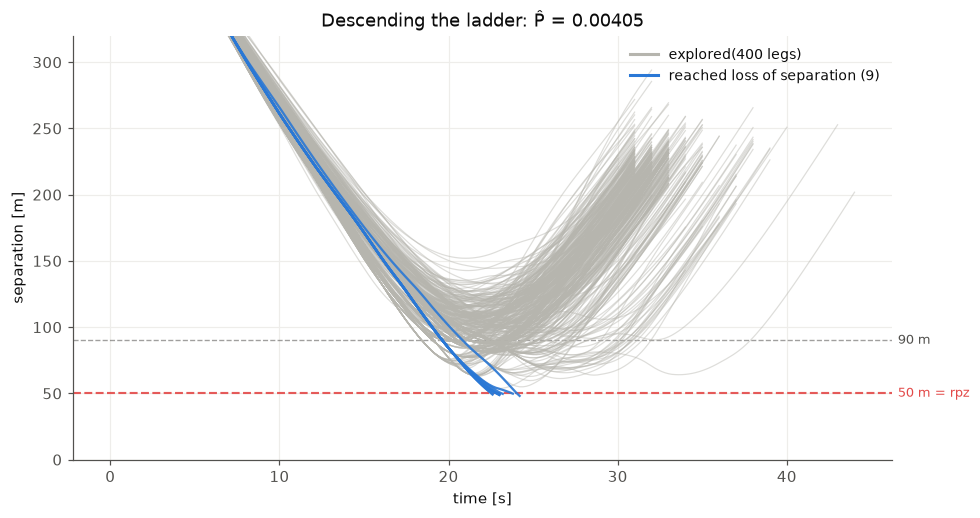

In [20]:
N = 200
LEVELS = [90.0, 50.0]

print(f"ladder, N = {N} particles, replication 0 of seed {SEED}:")
rep_seq = child(root_seed_sequence(SEED), 0)      # what estimate_rare_prob hands rep 0
survival, p_hat, explored, (final_particles, final_trajs) = run_ladder(rep_seq, LEVELS, N)

print(f"\n  P̂ = {' × '.join(f'{s:.3f}' for s in survival)} = {p_hat:.4g}")

fig, ax = plt.subplots(figsize=(8.8, 4.6))
for traj in explored:
    a = np.asarray(traj)
    ax.plot(a[:, 0], a[:, 1], color=GRAY, lw=0.8, alpha=0.45, zorder=2)
reached = [t for p, t in zip(final_particles, final_trajs) if p.min_sep <= RPZ]
for traj in reached:
    a = np.asarray(traj)
    ax.plot(a[:, 0], a[:, 1], color=BLUE, lw=1.5, alpha=0.9, zorder=3)
_levels_on(ax, levels = LEVELS)
ax.plot([], [], color=GRAY, lw=2, label=f"explored({len(explored)} legs)")
ax.plot([], [], color=BLUE, lw=2, label=f"reached loss of separation ({len(reached)})")
ax.legend(frameon=False, loc="upper right", fontsize=9)
ax.set(xlabel="time [s]", ylabel="separation [m]", ylim=(0, 320),
       title=f"Descending the ladder: P̂ = {p_hat:.4g}")
plt.show()

## 5 · Cross-check: is this the same estimator?

The from-scratch ladder above used the package's exact stream addressing, so the packaged
estimator — called with the same seed, ladder and particle count — must return the
**identical survival tuple**, not merely a similar number. That equality is the proof the
notebook rebuilt the real thing rather than something that resembles it. This is the only
cell that touches `blueskycdarr.ips`, and only to check.

One honest caveat about the number itself: `P̂` above is **one replication at N = 20**,
chosen so the notebook runs in seconds. It is a point estimate with a lot of spread — a
production estimate averages many independent ladders (`estimate_rare_prob(..., reps=…)`),
because particles within a single run interact through resampling and one run's spread
understates the real one.

In [18]:
from blueskycdarr.ips import estimate_rare_prob      # the only ips import, for checking

est = estimate_rare_prob(SCENARIO, MULTIROTOR, CONFIG, levels=LEVELS,
                         n_particles=N, reps=1, seed=SEED, progress=True)
print()
print(est)

print("\npackaged   :", est.reps[0].survival)
print("from scratch:", survival)
assert est.reps[0].survival == survival, "the notebook diverged from the estimator!"
assert est.reps[0].prob == p_hat, "same survival fractions must give the same estimate"
print(f"\nidentical — P̂ = {p_hat:.4g}")

[rep 1/1] level 90 m, 9.0% survived
[rep 1/1] level 50 m, 4.5% survived
[rep 1/1] level 32 m, 9.0% survived
[rep 1/1] level 10 m, 5.0% survived
[rep 1/1] level 2 m, 1.0% survived

IPSEstimate  P(LoS) 1.82e-07 over 1 replications
  survival   levels (90, 50, 32, 10, 2) m | mean per level 0.09, 0.045, 0.09, 0.05, 0.01
  collapsed  0 of 1 replications
  lineages   2 distinct survivors behind the final clouds (per-replication record: reps)

packaged   : (0.09, 0.045, 0.09, 0.05, 0.01)
from scratch: (0.09, 0.045, 0.09, 0.05, 0.01)

identical — P̂ = 1.823e-07
